# Lab02: análisis y figuras

Este notebook **no calcula nada nuevo**: lee las tablas que deja `python main.py` en `docs/tables`, muestra las figuras de `docs/figures` y vuelve a dibujar las figuras 4 y 5 con las funciones de `src/plots.py`. Primero hay que correr `python main.py` desde la raíz del repositorio.

In [1]:
import json
import tempfile
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from src import plots

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TABLES, FIGURES = ROOT / 'docs' / 'tables', ROOT / 'docs' / 'figures'
pd.set_option('display.width', 200)


def table(name):
    return pd.read_csv(TABLES / f'{name}.csv', index_col=0)


def figure(name, folder=FIGURES):
    display(Image(filename=str(folder / name)))


REDRAWN = Path(tempfile.mkdtemp())  # las figuras que se redibujan aquí no tocan docs/

## 1. Métricas de desempeño

Entrenamiento (Jul-Nov 2023): semanas fuera de muestra del walk-forward semanal. Prueba (Dic 2023) y validación (May-Jun 2024): parámetros congelados antes de evaluar. Los tres periodos no tienen huecos.

In [2]:
display(table('periodos'))
for name, label in (('train', 'Entrenamiento'), ('test', 'Prueba'), ('validacion', 'Validación')):
    print(label)
    display(table(f'metricas_{name}').round(3))

,archivo,primera_barra,ultima_barra,barras,dias_con_datos
train,train,2023-07-01 00:00:00+00:00,2023-11-30 23:55:00+00:00,43171,149.9
test,train,2023-12-01 00:00:00+00:00,2023-12-31 00:00:00+00:00,8572,29.8
validacion,test,2024-05-02 13:30:00+00:00,2024-06-03 03:25:00+00:00,9079,31.5


Entrenamiento


,retorno_total,retorno_anual,volatilidad_anual,sharpe,sortino,max_drawdown,calmar,n_operaciones,win_rate,turnover_anual,costos_totales
theta_unico,-0.070,-0.199,0.080,-2.731,-3.695,-0.090,-2.203,43.0,0.465,88.657,35572.946
theta_por_regimen,-0.090,-0.252,0.155,-1.798,-2.608,-0.131,-1.923,101.0,0.386,286.398,114797.693
comprar_y_mantener,0.291,1.191,0.385,2.230,3.299,-0.171,6.967,0.0,NaN,0.000,0.000


Prueba


,retorno_total,retorno_anual,volatilidad_anual,sharpe,sortino,max_drawdown,calmar,n_operaciones,win_rate,turnover_anual,costos_totales
theta_unico,0.000,0.000,0.000,NaN,NaN,0.000,NaN,0.0,NaN,0.000,0.000
theta_por_regimen,-0.031,-0.324,0.072,-5.378,-7.202,-0.039,-8.310,19.0,0.474,92.184,9298.381
comprar_y_mantener,0.119,2.973,0.422,3.478,4.829,-0.097,30.628,0.0,NaN,0.000,0.000


Validación


,retorno_total,retorno_anual,volatilidad_anual,sharpe,sortino,max_drawdown,calmar,n_operaciones,win_rate,turnover_anual,costos_totales
theta_unico,0.000,0.000,0.000,NaN,NaN,0.000,NaN,0.0,NaN,0.000,0.000
theta_por_regimen,-0.030,-0.296,0.068,-5.091,-6.810,-0.040,-7.402,18.0,0.389,91.774,9822.592
comprar_y_mantener,0.164,4.787,0.407,4.520,6.593,-0.079,60.771,0.0,NaN,0.000,0.000


## 2. Figura 1. Valor del portafolio

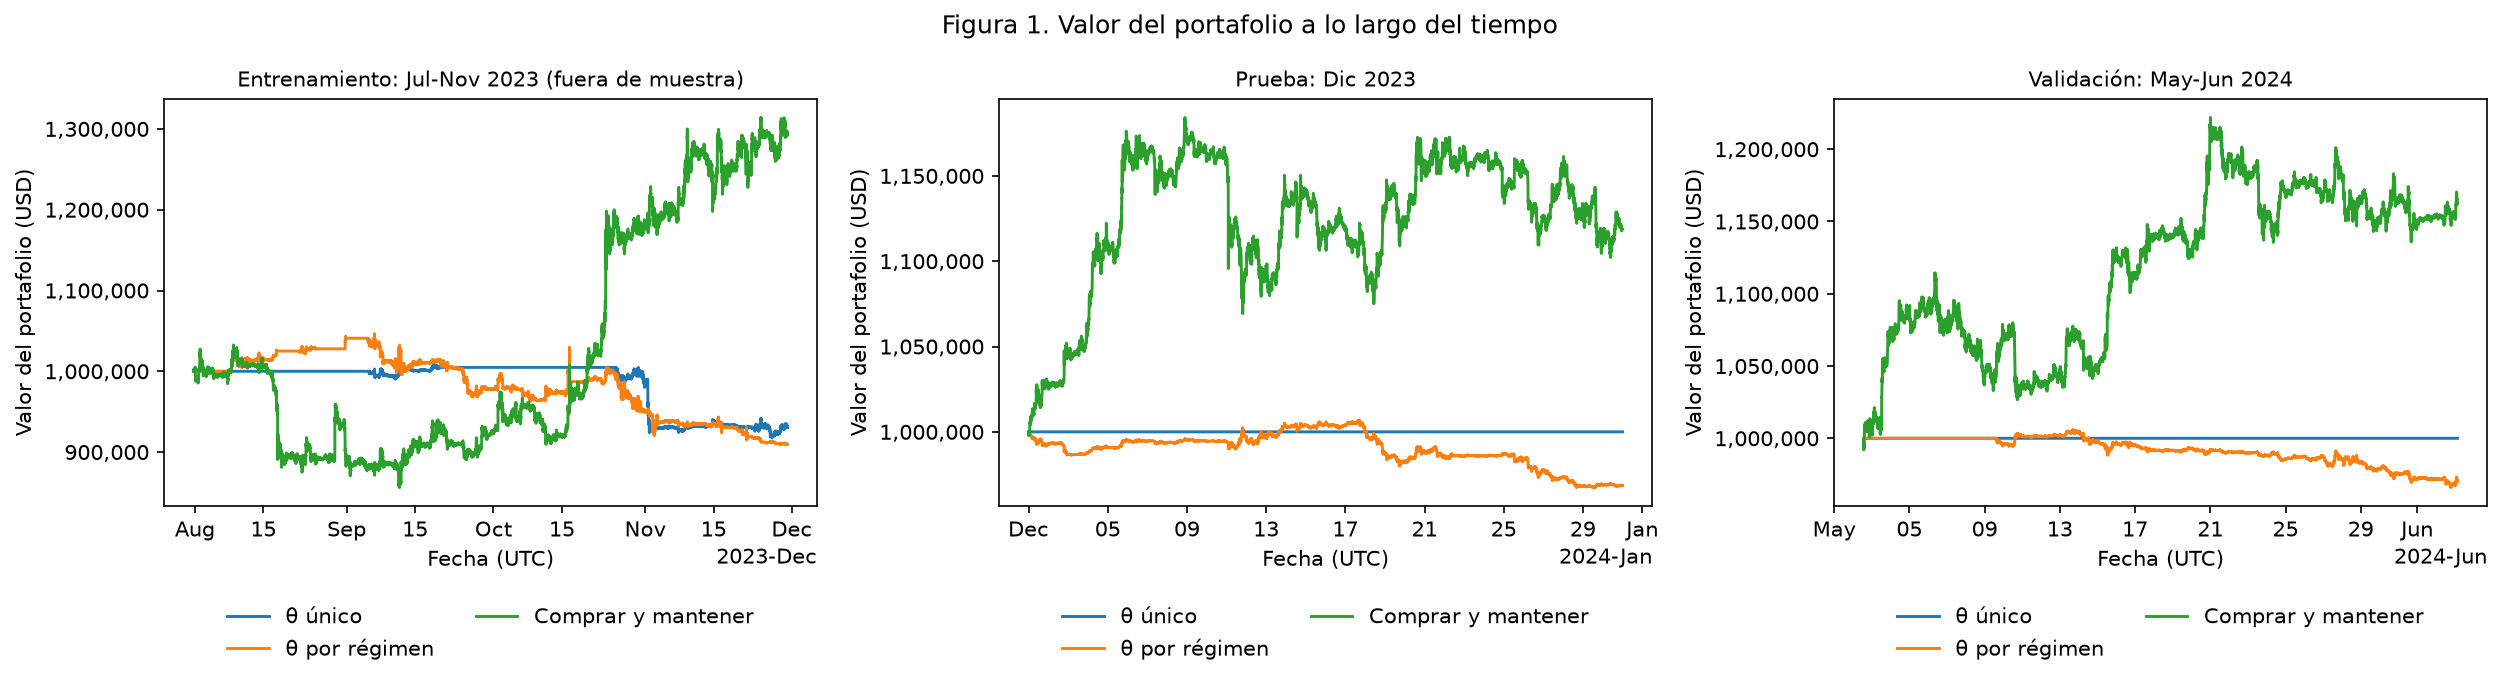

In [3]:
figure('fig1_valor_portafolio.png')

## 3. Figura 2. Drawdown

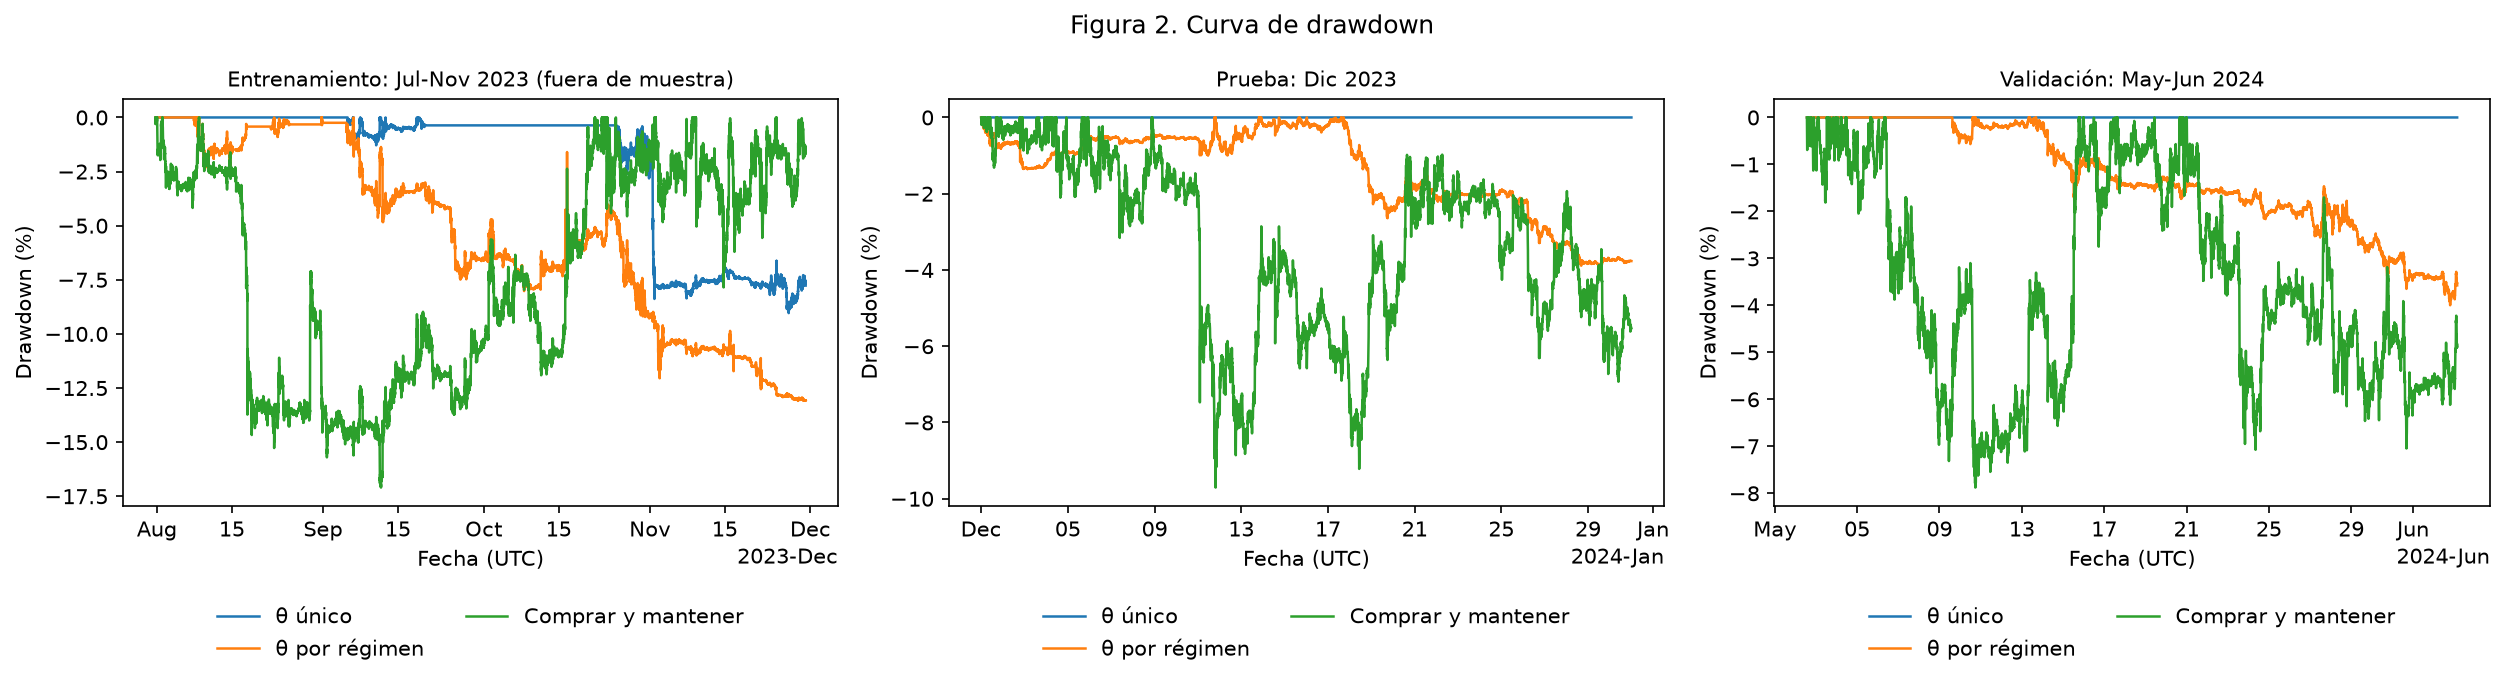

In [4]:
figure('fig2_drawdown.png')

## 4. Figura 3. Retornos mensuales, trimestrales y anuales

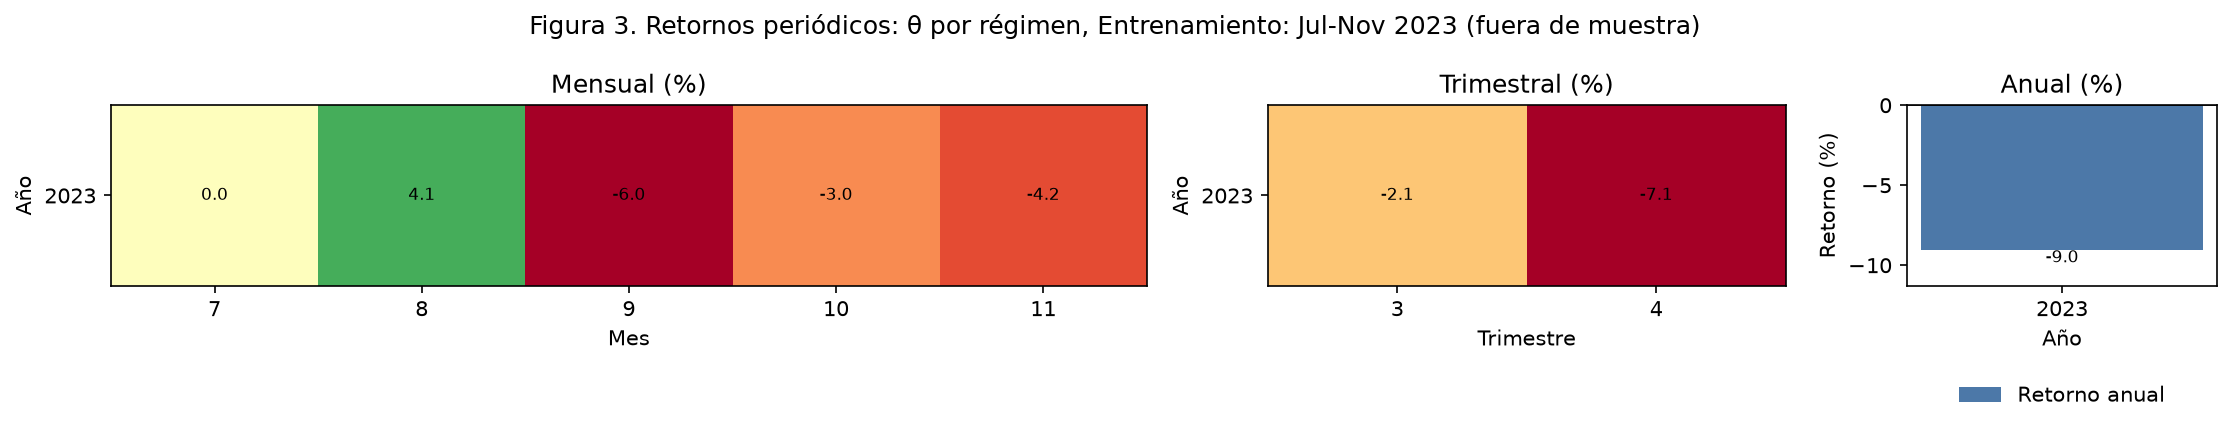

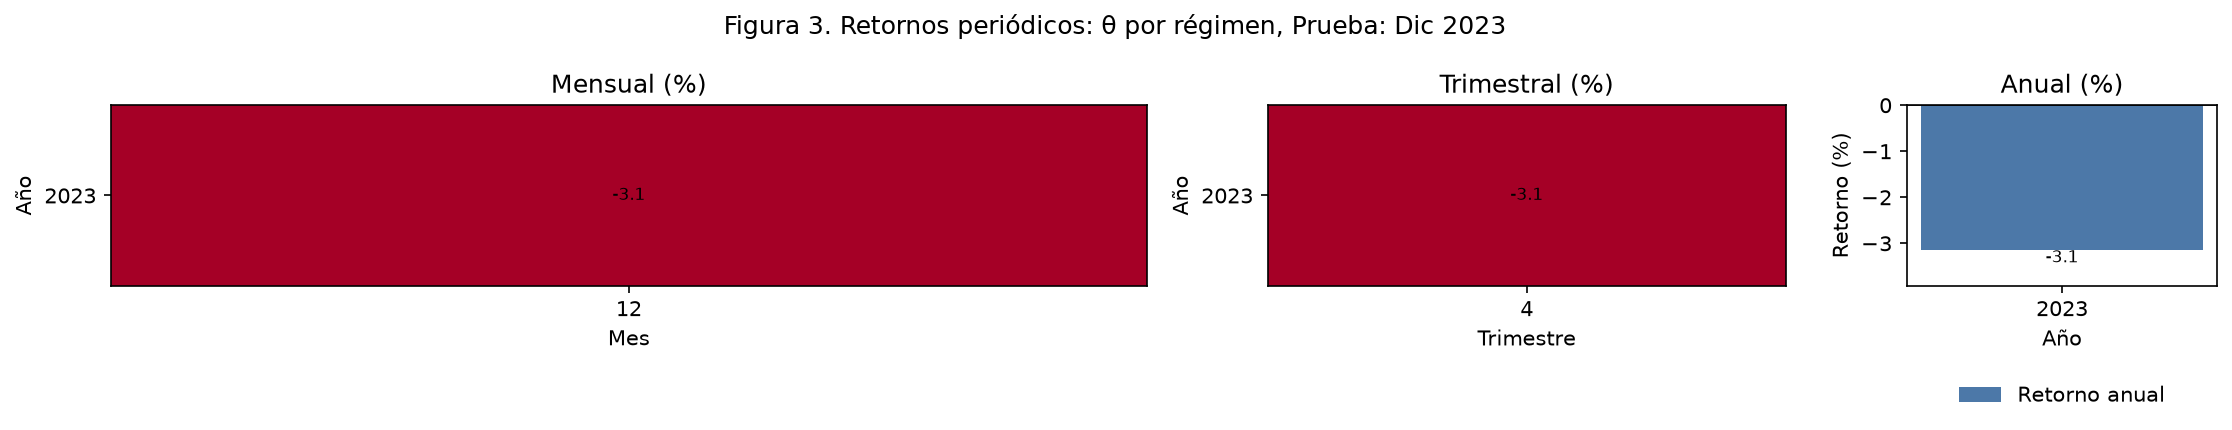

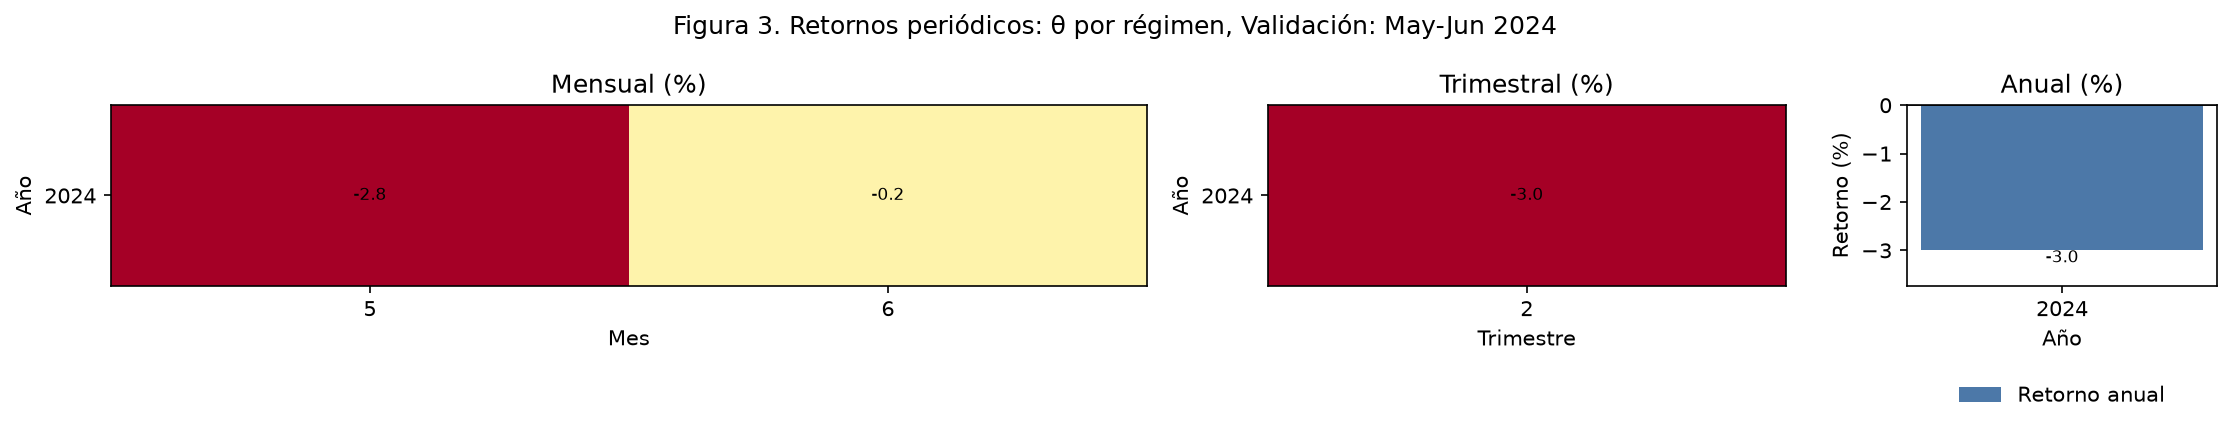

In [5]:
figure('fig3_retornos_entrenamiento.png')
figure('fig3_retornos_prueba.png')
figure('fig3_retornos_validacion.png')

## 5. Figura 4. Sensibilidad de los parámetros (±20%)

Con la estrategia por régimen, porque el θ único no pasó el filtro de calidad. Redibujada con `plots.plot_sensitivity` a partir de la tabla guardada, en una carpeta temporal.

base_calmar  base_retorno  calmar_-20%  retorno_-20%  calmar_+20%  retorno_+20%
reversion n_donchian        2.983         0.088        2.355         0.070        2.779         0.083
          n_roc             2.983         0.088        3.001         0.089        0.995         0.031
          n_ema             2.983         0.088        2.810         0.083        2.950         0.087
          n_atr             2.983         0.088        2.837         0.089        3.366         0.094
          k                 2.983         0.088        3.045         0.090        2.718         0.081
          m                 2.983         0.088        3.050         0.111        3.505         0.085
          r                 2.983         0.088        3.302         0.097        2.983         0.088
          max_hold          2.983         0.088        2.983         0.088        2.983         0.088
          risk_frac         2.983         0.088        3.432         0.082        2.703         0.095
tendencia n_donchian        2.983         0.088        2.967         0.088        2.723         0.081
          n_roc             2.983         0.088        2.927         0.087        2.779         0.082
          n_ema             2.983         0.088        2.983         0.088        2.987         0.088
          n_atr             2.983         0.088        2.753         0.081        2.602         0.077
          k                 2.983         0.088        2.994         0.088        2.983         0.088
          m                 2.983         0.088        2.289         0.068        2.497         0.074
          r                 2.983         0.088        2.830         0.084        2.627         0.078
          max_hold          2.983         0.088        2.983         0.088        2.983         0.088
          risk_frac         2.983         0.088        2.754         0.082        3.215         0.094
crisis    n_donchian        2.983         0.088        2.983         0.088        2.778         0.082
          n_roc             2.983         0.088        2.983         0.088        2.778         0.082
          n_ema             2.983         0.088        2.983         0.088        2.983         0.088
          n_atr             2.983         0.088        2.973         0.088        2.939         0.087
          k                 2.983         0.088        2.983         0.088        2.983         0.088
          m                 2.983         0.088        2.993         0.088        2.819         0.083
          r                 2.983         0.088        2.983         0.088        2.983         0.088
          max_hold          2.983         0.088        2.260         0.068        2.085         0.063
          risk_frac         2.983         0.088        2.786         0.082        3.181         0.093

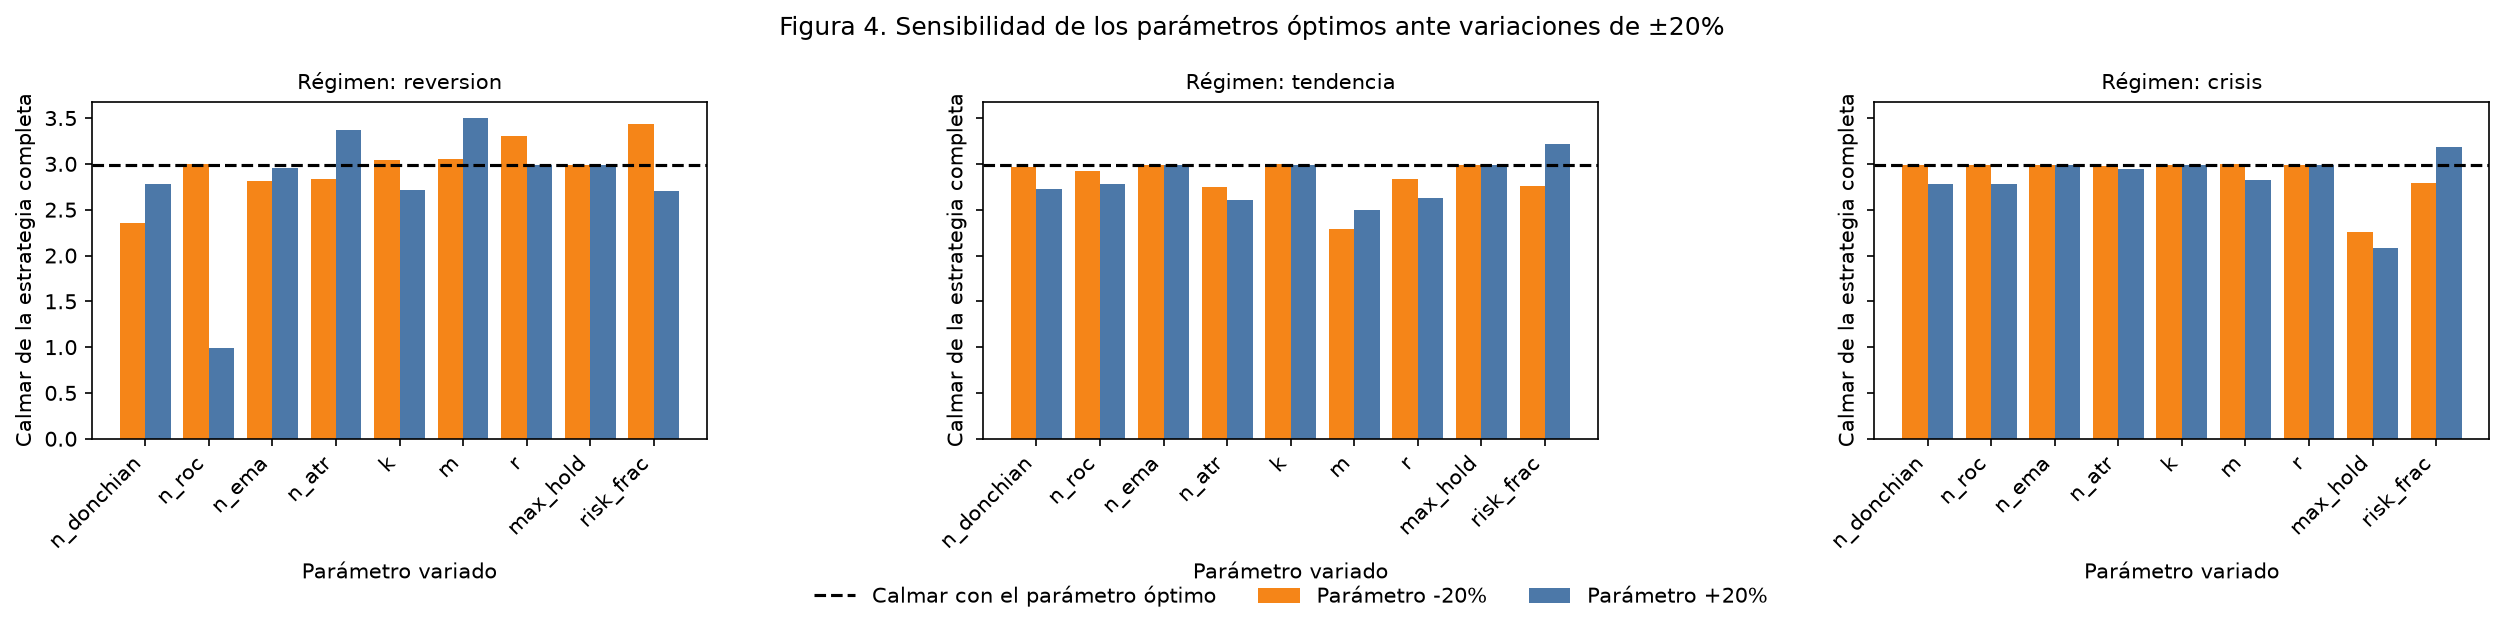

In [6]:
sens = pd.read_csv(TABLES / 'pregunta3_sensibilidad.csv', index_col=[0, 1])
display(sens.round(3))
plots.plot_sensitivity(sens, REDRAWN / 'fig4_sensibilidad.png')
figure('fig4_sensibilidad.png', REDRAWN)

## 6. Figura 5. Retorno contra costo de transacción

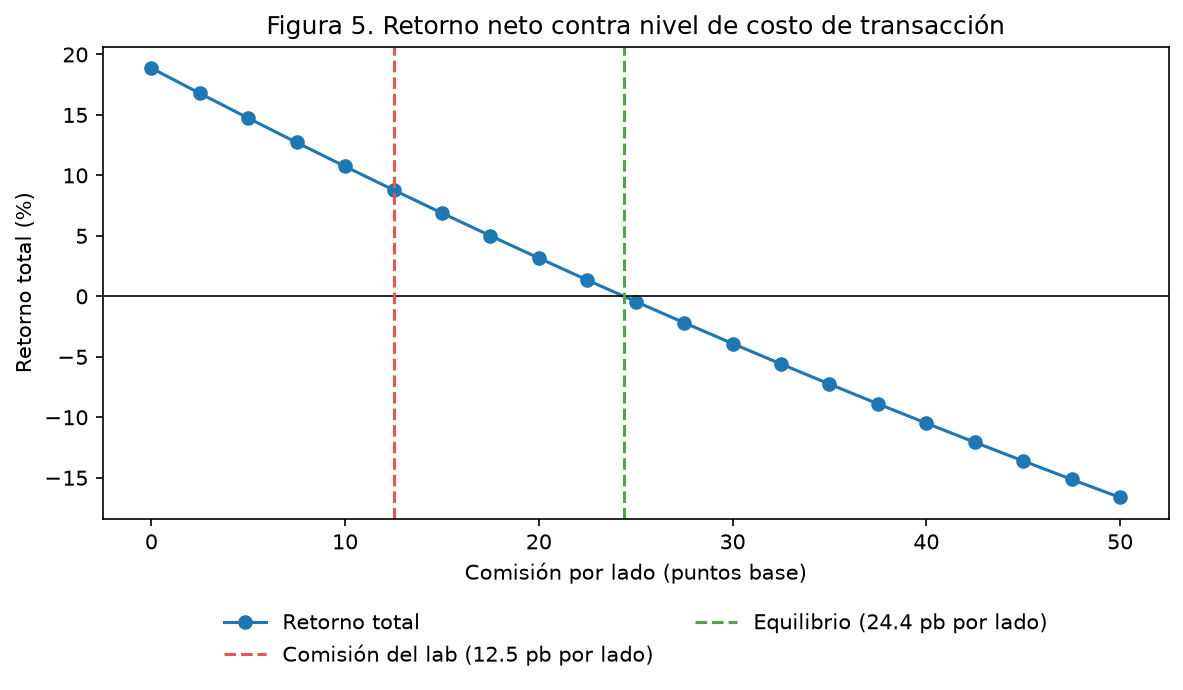

In [7]:
curve = table('pregunta4_curva_de_costos')
resumen = json.loads((TABLES / 'resumen.json').read_text())
plots.plot_cost_curve(curve, resumen.get('comision_equilibrio_bps_por_lado'), 12.5, REDRAWN / 'fig5_costos.png')
figure('fig5_costos.png', REDRAWN)

## 7. Figura 6. Regímenes de mercado

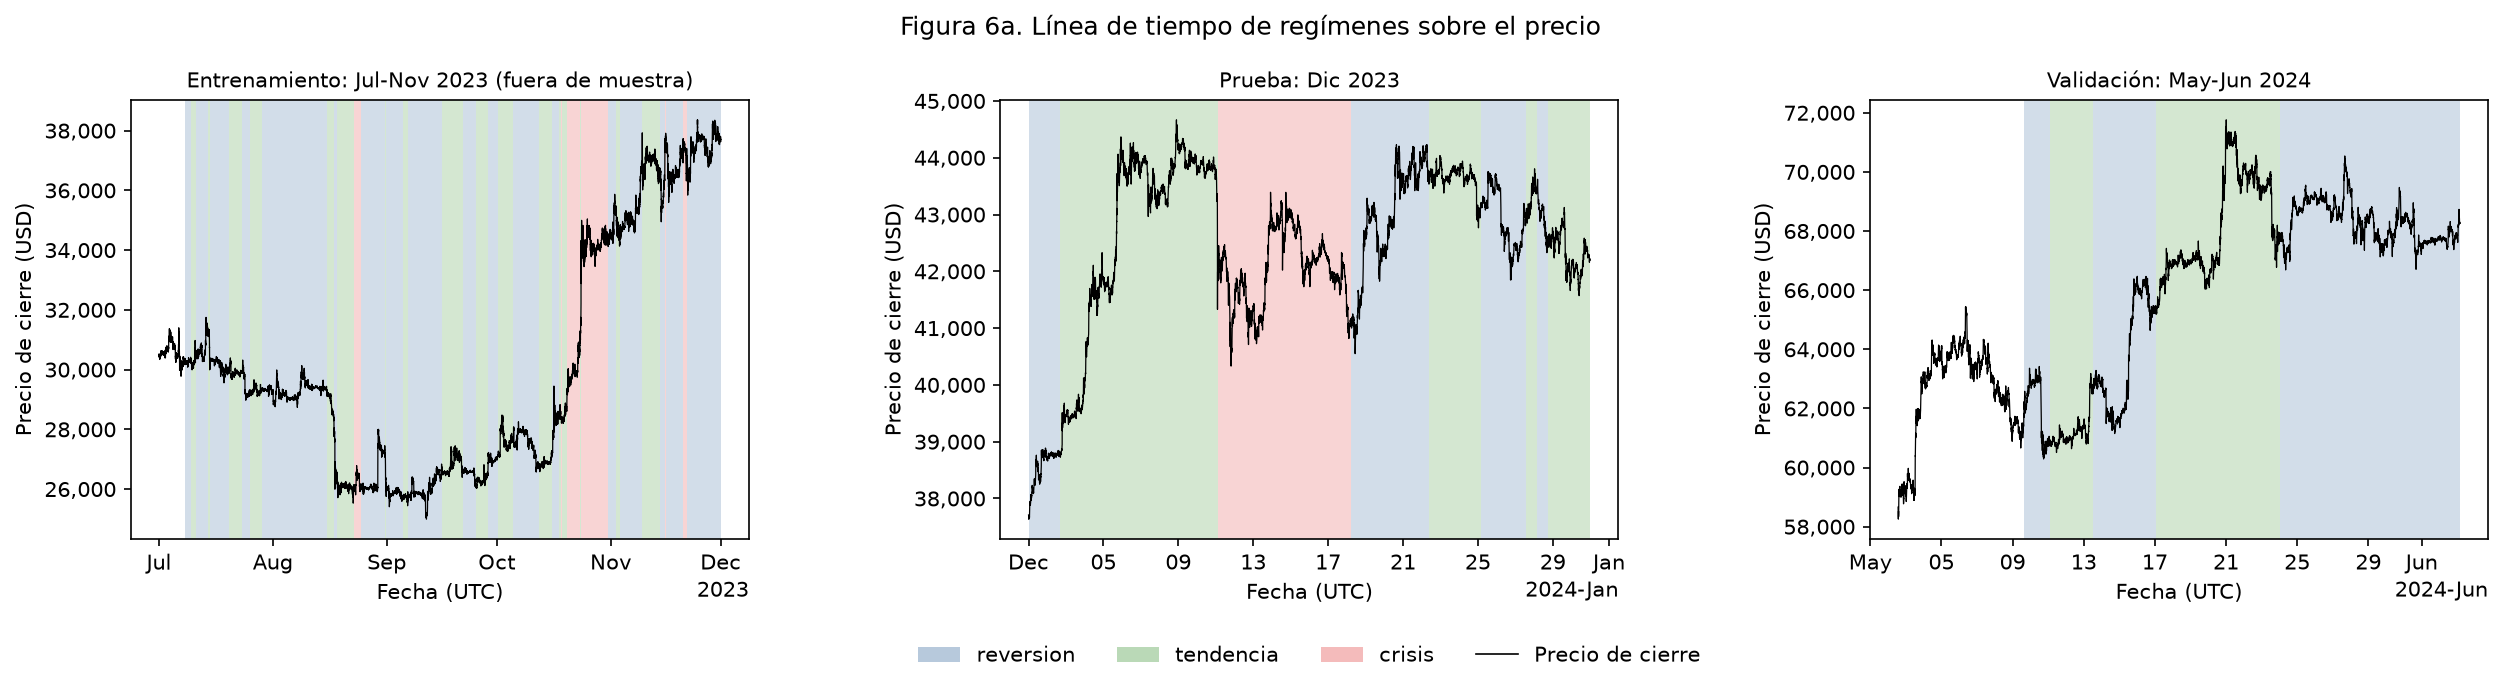

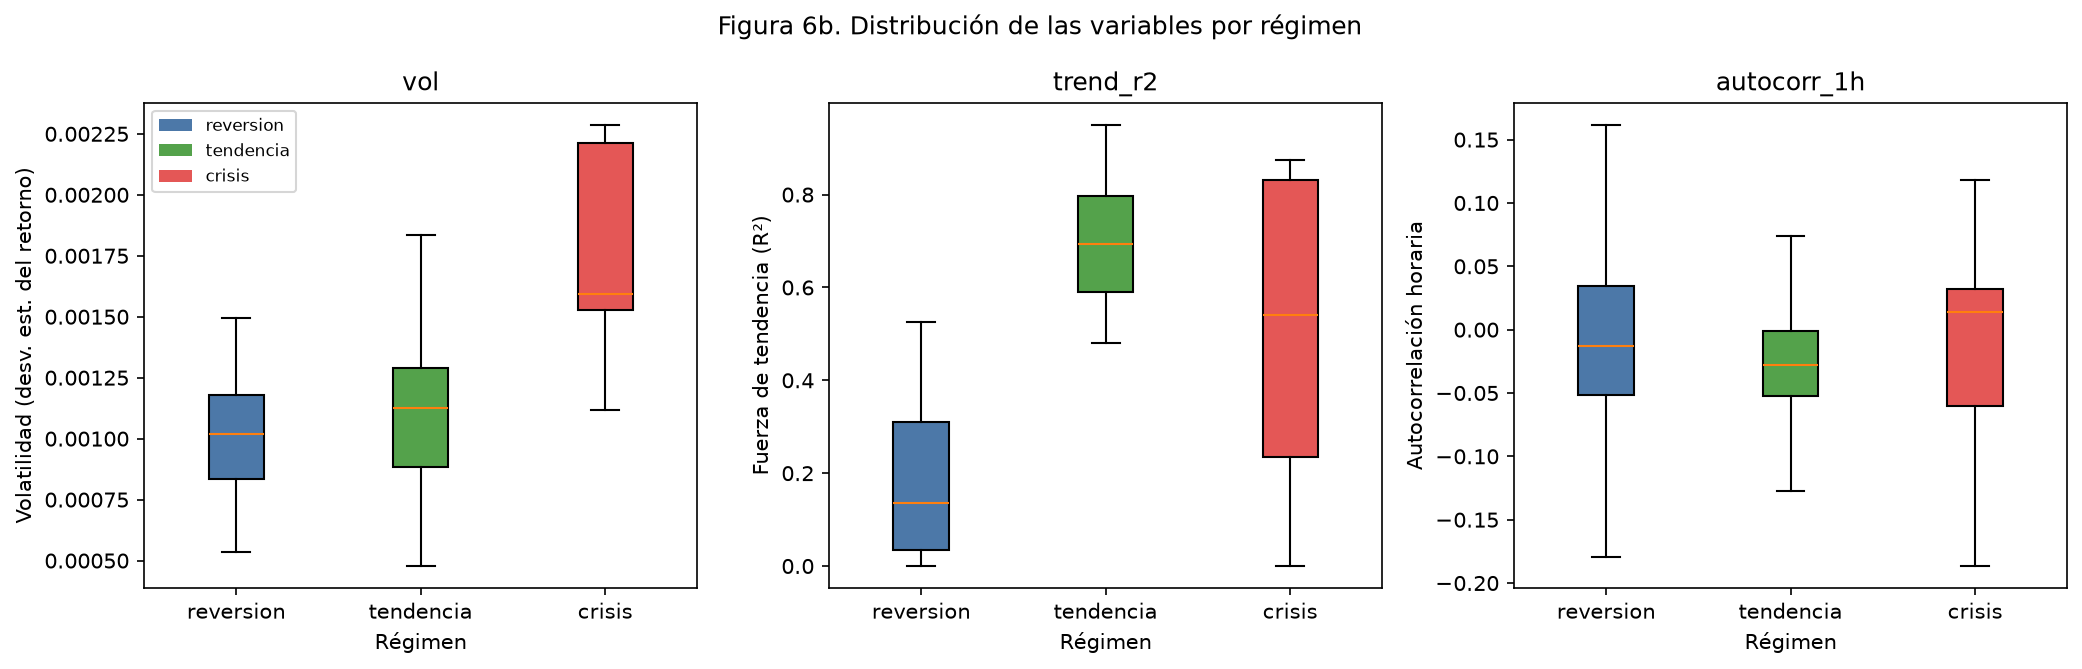

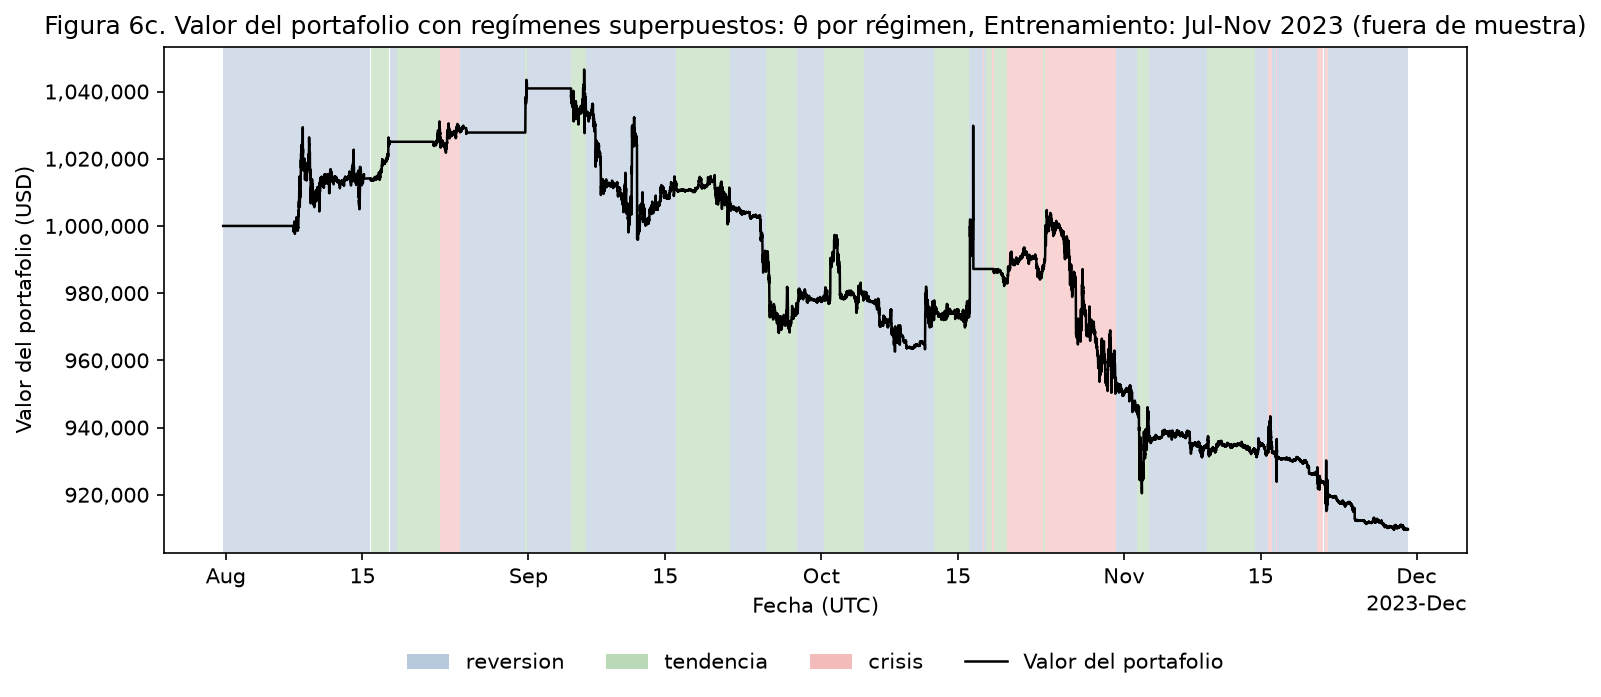

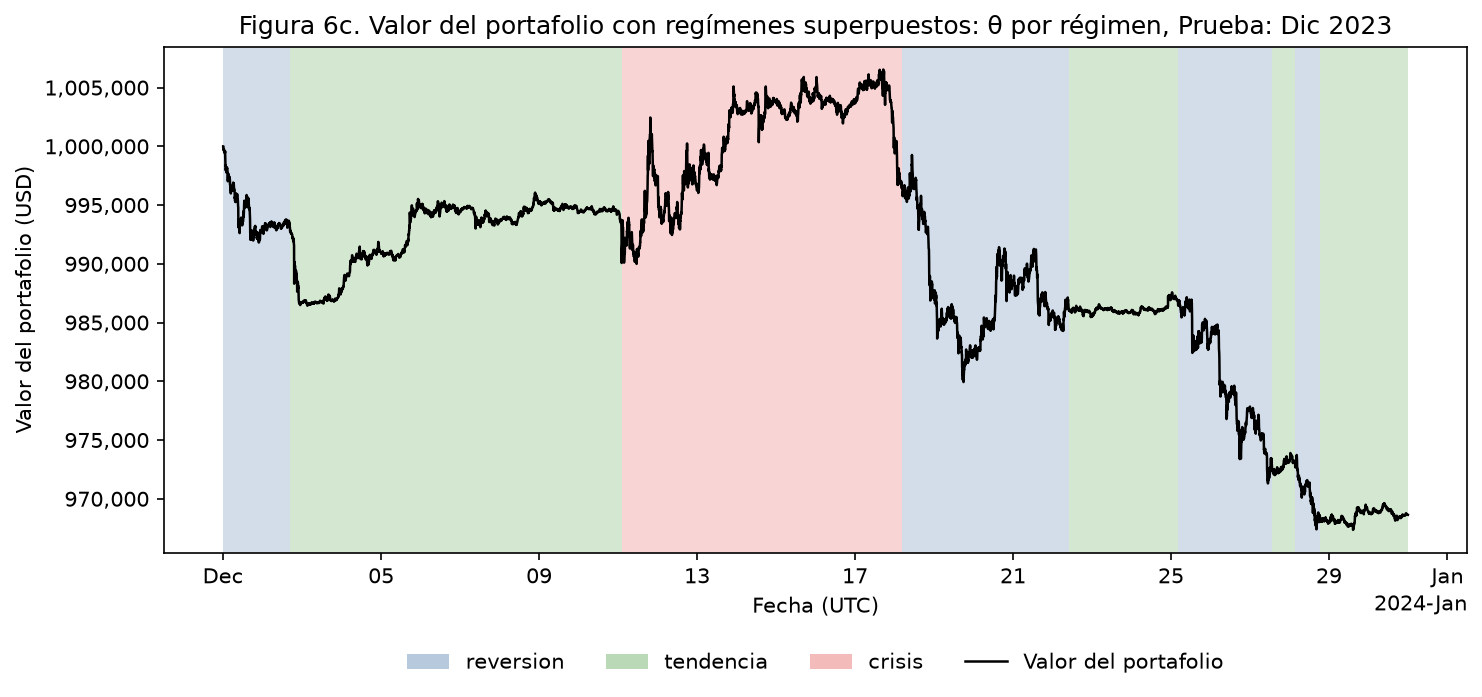

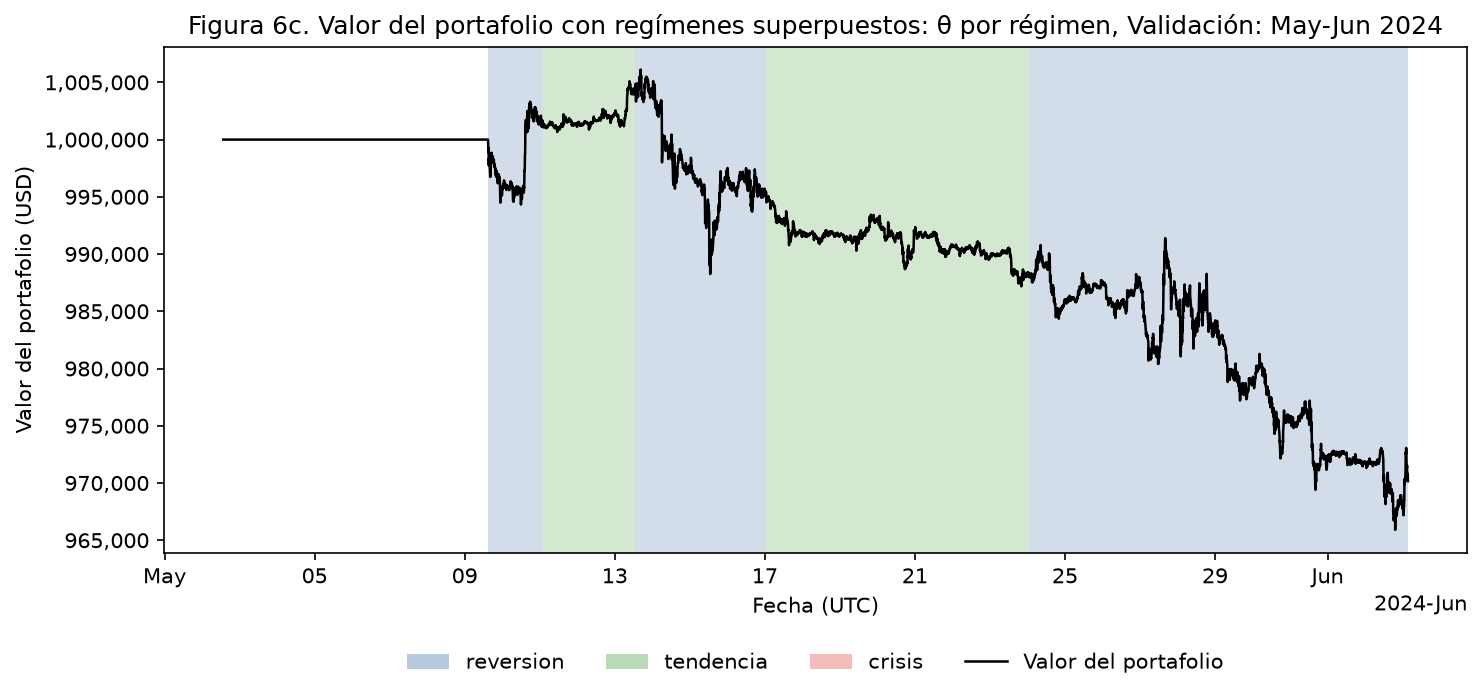

In [8]:
figure('fig6a_regimenes_precio.png')
figure('fig6b_distribuciones.png')
for name in ('entrenamiento', 'prueba', 'validacion'):
    figure(f'fig6c_portafolio_regimenes_{name}.png')

## 8. Estabilidad del régimen: entrenamiento, prueba y validación

In [9]:
for name in ('train', 'test', 'validacion'):
    print(name)
    display(table(f'regimenes_{name}').round(1))
    display(table(f'regimenes_{name}_global').round(3))

train


,participacion_%,duracion_media_h,duracion_mediana_h,rachas
reversion,61.6,100.6,76.0,21.0
tendencia,28.3,54.0,39.5,18.0
crisis,10.0,34.4,7.5,10.0


,valor
transiciones_por_mes,10.077
silhouette,0.408


test


,participacion_%,duracion_media_h,duracion_mediana_h,rachas
reversion,29.7,53.1,48.2,4.0
tendencia,46.7,83.5,59.5,4.0
crisis,23.5,168.0,168.0,1.0


,valor
transiciones_por_mes,8.063
silhouette,0.481


validacion


,participacion_%,duracion_media_h,duracion_mediana_h,rachas
reversion,61.4,120.5,84.0,3.0
tendencia,38.6,113.5,113.5,2.0
crisis,0.0,NaN,NaN,0.0


,valor
transiciones_por_mes,4.893
silhouette,0.469


## 9. Desempeño por régimen y cómo terminan las operaciones

In [10]:
for dataset in ('train', 'test', 'validacion'):
    print(dataset)
    display(table(f'desempeno_por_regimen_{dataset}').round(3))
    display(table(f'salidas_por_motivo_{dataset}'))

train


,operaciones,win_rate,bruto_medio_pct,neto_medio_pct,neto_desv_pct,razon_media_desv,contribucion_capital_pct
regimen,,,,,,,
crisis,25,0.280,-0.020,-0.271,1.569,-0.173,-5.918
reversion,54,0.389,-0.169,-0.420,1.530,-0.274,-2.594
tendencia,22,0.500,0.598,0.348,1.991,0.175,-0.538


,operaciones
reason,
signal,36
regime_change,35
segment_end,13
stop_loss,11
take_profit,4
max_hold,2


test


,operaciones,win_rate,bruto_medio_pct,neto_medio_pct,neto_desv_pct,razon_media_desv,contribucion_capital_pct
regimen,,,,,,,
crisis,5,0.600,0.981,0.731,2.418,0.302,0.442
reversion,9,0.222,-1.374,-1.625,1.696,-0.958,-3.590
tendencia,5,0.800,1.401,1.149,3.194,0.360,0.012


,operaciones
reason,
regime_change,8
signal,5
max_hold,3
stop_loss,2
segment_end,1


validacion


,operaciones,win_rate,bruto_medio_pct,neto_medio_pct,neto_desv_pct,razon_media_desv,contribucion_capital_pct
regimen,,,,,,,
reversion,15,0.400,-0.431,-0.681,1.494,-0.456,-2.629
tendencia,3,0.333,-0.659,-0.912,3.717,-0.245,-0.355


,operaciones
reason,
signal,12
regime_change,4
stop_loss,1
segment_end,1


## 10. Selección de indicadores (sin mirar retornos)

Correlación media y máxima entre las señales de cada trío con un indicador por familia.

In [11]:
display(table('correlacion_trios').round(3))
display(table('correlacion_indicadores').round(2))

,correlacion_media,correlacion_maxima
ema_cross + rsi + keltner,0.554,0.667
ema_cross + roc + keltner,0.427,0.536
donchian + rsi + keltner,0.448,0.667
donchian + roc + keltner,0.335,0.536


,ema_cross,donchian,rsi,roc,keltner
ema_cross,1.00,0.68,0.58,0.33,0.41
donchian,0.68,1.00,0.38,0.17,0.30
rsi,0.58,0.38,1.00,0.69,0.67
roc,0.33,0.17,0.69,1.00,0.54
keltner,0.41,0.30,0.67,0.54,1.00


## 11. Exposición al mercado en prueba y validación

Fracción de barras con posición abierta y exposición media (nocional entre valor del portafolio). Explica por qué la volatilidad de la estrategia es tan baja.

In [12]:
for name in ('test', 'validacion'):
    path = TABLES / f'exposicion_{name}.csv'
    print(name)
    if path.exists():
        display(pd.read_csv(path, index_col=0).round(1))
    else:
        print('Corre python main.py para generar', path.name)

test


,barras_con_posicion_%,exposicion_media_%,exposicion_maxima_%
theta_unico,0.0,0.0,0.0
theta_por_regimen,99.8,15.3,31.1


validacion


,barras_con_posicion_%,exposicion_media_%,exposicion_maxima_%
theta_unico,0.0,0.0,0.0
theta_por_regimen,77.8,18.8,37.1


## 12. Respuestas con cifras propias

In [13]:
display(table('pregunta1_dos_de_tres').round(3))
print(json.dumps(resumen, indent=2))

,n_operaciones,retorno_total,calmar,sharpe,win_rate
donchian,120.0,0.018,0.456,0.450,0.400
roc,129.0,0.059,2.090,1.360,0.450
keltner,107.0,-0.037,-0.944,-0.757,0.327
2 de 3,117.0,0.088,2.983,1.945,0.436


{
  "pruebas_por_ventana": 150,
  "ventanas": 17,
  "calmar_entrenamiento_mediano": -1.1907560427245598,
  "calmar_fuera_de_muestra": -2.2029143994534723,
  "diferenciacion_reversion_vs_tendencia": {
    "diferencia_media": -0.767104637552554,
    "p_welch": 0.11487358951538544,
    "ic95_bajo": -1.7236691926378789,
    "ic95_alto": 0.08890067146051524
  },
  "configuraciones_walk_forward_theta_unico": 2550,
  "configuraciones_walk_forward_por_regimen": 7500,
  "configuraciones_theta_congelado": 600,
  "comision_equilibrio_bps_por_lado": 24.394537823500634,
  "configuraciones_totales": 10650,
  "tiempo_total_s": 365
}
